In [2]:
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
from lifelines.utils import restricted_mean_survival_time

from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import utils_process
import itertools

## Read observational data

In [ ]:
df_proact = pd.read_csv("../_data/PROACT_data.csv").set_index(["ID","TIME"])
df_proact["ARM"] = df_proact["ARM"].fillna("Observational")
df_proact= df_proact[df_proact["ARM"]=="Observational"]
df_proact = df_proact[df_proact["ONSET_SYMPTOMS"].isin(["BULBAR","SPINAL", "SPINAL_AND_BULBAR"])]
df_proact["SEX"] = df_proact["SEX"].replace({"Male": 1, "Female": 0})
df_proact["ONSET_SYMPTOMS"] = df_proact["ONSET_SYMPTOMS"].replace({"SPINAL": 1, "BULBAR": 0, "SPINAL_AND_BULBAR": 2})

/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/957303245.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_proact["SEX"] = df_proact["SEX"].replace({"Male": 1, "Female": 0})
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/957303245.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_proact["ONSET_SYMPTOMS"] = df_proact["ONSET_SYMPTOMS"].replace({"SPINAL": 1, "BULBAR": 0, "SPINAL_AND_BULBAR": 2})


In [ ]:
df_pulse = pd.read_csv("../_data/PULSE_data.csv").set_index(["ID","TIME"])
df_pulse= df_pulse[df_pulse["ARM"]=="Case"]
df_pulse["ONSET_SYMPTOMS"] = df_pulse["ONSET_SYMPTOMS"].replace({"UPPER_SPINAL": "SPINAL", "LOWER_SPINAL": "SPINAL"})
df_pulse = df_pulse[df_pulse["ONSET_SYMPTOMS"].isin(["BULBAR","SPINAL","SPINAL_AND_BULBAR"])]
df_pulse["SEX"] = df_pulse["SEX"].replace({"Male": 1, "Female": 0})
df_pulse["ONSET_SYMPTOMS"] = df_pulse["ONSET_SYMPTOMS"].replace({"SPINAL": 1, "BULBAR": 0, "SPINAL_AND_BULBAR": 2})

/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/1511885578.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_pulse["SEX"] = df_pulse["SEX"].replace({"Male": 1, "Female": 0})
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/1511885578.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_pulse["ONSET_SYMPTOMS"] = df_pulse["ONSET_SYMPTOMS"].replace({"SPINAL": 1, "BULBAR": 0, "SPINAL_AND_BULBAR": 2})


In [ ]:
df_neurobank = pd.read_csv("../_data/NEUROBANK_data.csv").set_index(["ID","TIME"])
df_neurobank["ONSET_SYMPTOMS"] = df_neurobank["ONSET_SYMPTOMS"].replace({"UPPER_SPINAL": "SPINAL", "LOWER_SPINAL": "SPINAL"})
df_neurobank = df_neurobank[df_neurobank["ONSET_SYMPTOMS"].isin(["BULBAR","SPINAL","SPINAL_AND_BULBAR"])]
#Remove patients dead before baseline
df_neurobank = df_neurobank[df_neurobank["AGE_AT_DEATH"]>=df_neurobank["AGE_AT_BASELINE"]]  
df_neurobank["SEX"] = df_neurobank["SEX"].replace({"Male": 1, "Female": 0})
df_neurobank["ONSET_SYMPTOMS"] = df_neurobank["ONSET_SYMPTOMS"].replace({"SPINAL": 1, "BULBAR": 0, "SPINAL_AND_BULBAR": 2})

/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/1408897047.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_neurobank["SEX"] = df_neurobank["SEX"].replace({"Male": 1, "Female": 0})
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/1408897047.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_neurobank["ONSET_SYMPTOMS"] = df_neurobank["ONSET_SYMPTOMS"].replace({"SPINAL": 1, "BULBAR": 0, "SPINAL_AND_BULBAR": 2})


In [ ]:
df_answerals = pd.read_csv("../_data/ANSWERALS_data.csv").set_index(["ID","TIME"])
df_answerals= df_answerals[df_answerals["ARM"]=="ALS"]
df_answerals["ONSET_SYMPTOMS"] = df_answerals["ONSET_SYMPTOMS"].replace({"UPPER_SPINAL": "SPINAL", "LOWER_SPINAL": "SPINAL"})
df_answerals = df_answerals[df_answerals["ONSET_SYMPTOMS"].isin(["BULBAR","SPINAL","SPINAL_AND_BULBAR"])] 
df_answerals["SEX"] = df_answerals["SEX"].replace({"Male": 1, "Female": 0})
df_answerals["ONSET_SYMPTOMS"] = df_answerals["ONSET_SYMPTOMS"].replace({"SPINAL": 1, "BULBAR": 0, "SPINAL_AND_BULBAR": 2})

/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/3455502025.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_answerals["SEX"] = df_answerals["SEX"].replace({"Male": 1, "Female": 0})
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/3455502025.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_answerals["ONSET_SYMPTOMS"] = df_answerals["ONSET_SYMPTOMS"].replace({"SPINAL": 1, "BULBAR": 0, "SPINAL_AND_BULBAR": 2})


## Process observational data for Cox

In [ ]:
covariates = [
    "AGE_AT_DIAGNOSIS",
    "SEX",
    "ONSET_SYMPTOMS",
    "ALSFRS_R_TOTAL",
    "BMI"
]

datasets = {
    "PROACT": df_proact,
    "PULSE": df_pulse,
    "NEUROBANK": df_neurobank,
    "ANSWERALS": df_answerals
}

cox_dfs = {}

for name, df in datasets.items():
    df_filtered = utils_process.process_delta_and_filter(df, covariates=covariates)

    # Create event dataframe
    df_event = utils_process.create_event_dataframe(df_filtered)
    print(f"Total number of patients in {name} after filtering on covariates: {len(df_event)}")

    # Create covariate dataframe
    df_cov = (
        df_filtered[covariates].groupby("ID").nth(0).reset_index(level=1, drop=True)
    )

    df_cox = pd.merge(df_event, df_cov, on="ID", how="inner").set_index("ID")
    cox_dfs[name] = df_cox

df_proact_cox = cox_dfs["PROACT"]
df_pulse_cox = cox_dfs["PULSE"]
df_neurobank_cox = cox_dfs["NEUROBANK"]
df_answerals_cox = cox_dfs["ANSWERALS"]


Total number of patients in PROACT after filtering on covariates: 343
Total number of patients in PULSE after filtering on covariates: 457
Total number of patients in NEUROBANK after filtering on covariates: 1101
Total number of patients in ANSWERALS after filtering on covariates: 768


## Read and process Trophos data

In [ ]:
# Process for survival 
df_trophos = pd.read_csv("../_data/TROPHOS_data.csv").set_index(["ID","TIME"])
df_trophos["SEX"] = df_trophos["SEX"].replace({"Male": 1, "Female": 0})
df_trophos["ONSET_SYMPTOMS"] = df_trophos["ONSET_SYMPTOMS"].replace({"SPINAL": 1, "BULBAR": 0})

df_trophos_filtered = utils_process.process_delta_and_filter(df_trophos, "AGE_MAX_AT_DEATH", "AGE_MIN_AT_DEATH", covariates=covariates)

intervals = [1/12, 3/12, 6/12, 9/12, 12/12, 18/12]
df_trophos_filtered_sim_events = utils_process.simulate_age_at_death(df_trophos_filtered, intervals)
df_trophos_active_event = utils_process.create_event_dataframe(df_trophos_filtered_sim_events[df_trophos_filtered_sim_events["ARM"]=="TRO19622"], delta_age_at_death_col="DELTA_AGE_AT_DEATH_SIM", delta_last_known_living_age_col="DELTA_LAST_KNOWN_LIVING_AGE_SIM")
df_trophos_placebo_event = utils_process.create_event_dataframe(df_trophos_filtered_sim_events[df_trophos_filtered_sim_events["ARM"]=="Placebo"], delta_age_at_death_col="DELTA_AGE_AT_DEATH_SIM", delta_last_known_living_age_col="DELTA_LAST_KNOWN_LIVING_AGE_SIM")
df_trophos_cov = df_trophos_filtered[covariates + ["ARM"]].groupby("ID").nth(0).reset_index(level=1, drop=True)

/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/1072800991.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_trophos["SEX"] = df_trophos["SEX"].replace({"Male": 1, "Female": 0})
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/1072800991.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_trophos["ONSET_SYMPTOMS"] = df_trophos["ONSET_SYMPTOMS"].replace({"SPINAL": 1, "BULBAR": 0})


In [10]:
 #Create df for cox
df_trophos_active_cox = pd.merge(
    df_trophos_active_event,
    df_trophos_cov[df_trophos_cov["ARM"]=="TRO19622"].reset_index(),
    on='ID',
    how='inner'
).set_index("ID")

df_trophos_placebo_cox = pd.merge(
    df_trophos_placebo_event,
    df_trophos_cov[df_trophos_cov["ARM"]=="Placebo"].reset_index(),
    on='ID',
    how='inner'
).set_index("ID")

# Clean Treatment column
df_trophos_placebo_cox = df_trophos_placebo_cox.rename(columns={"ARM": "TREATMENT"})
df_trophos_active_cox = df_trophos_active_cox.rename(columns={"ARM": "TREATMENT"})
df_trophos_placebo_cox["TREATMENT"] = df_trophos_placebo_cox["TREATMENT"].replace({"Placebo": 0})
df_trophos_active_cox["TREATMENT"] = df_trophos_active_cox["TREATMENT"].replace({"TRO19622": 1})

data_ct_cox = pd.concat([df_trophos_placebo_cox, df_trophos_active_cox], ignore_index=False)

/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/768981344.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_trophos_placebo_cox["TREATMENT"] = df_trophos_placebo_cox["TREATMENT"].replace({"Placebo": 0})
/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_67042/768981344.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_trophos_active_cox["TREATMENT"] = df_trophos_active_cox["TREATMENT"].replace({"TRO19622": 1})


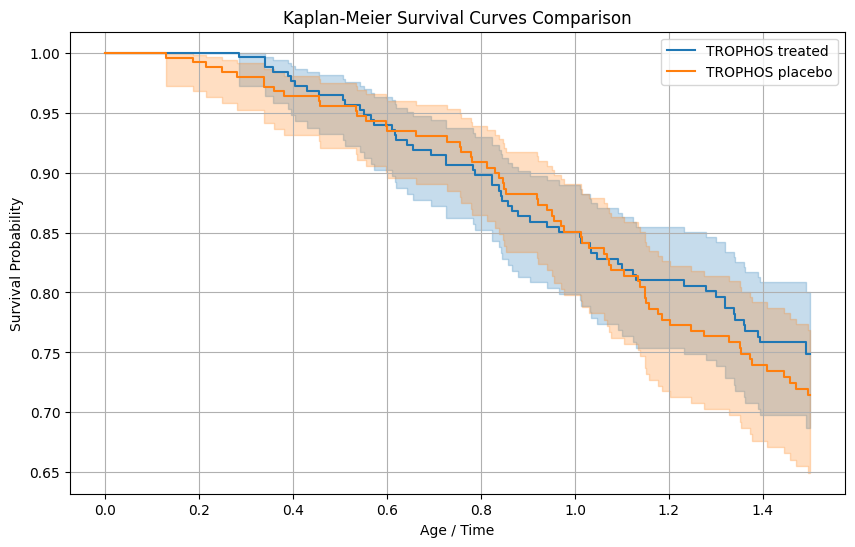

In [ ]:
# KM plots
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

kmf_trt = KaplanMeierFitter()
kmf_trt.fit(data_ct_cox[data_ct_cox["TREATMENT"]==1]["TIME_OF_EVENT"], data_ct_cox[data_ct_cox["TREATMENT"]==1]["EVENT"], label="TROPHOS treated")
kmf_trt.plot_survival_function(ci_show=True)
kmf_placebo = KaplanMeierFitter()
kmf_placebo.fit(data_ct_cox[data_ct_cox["TREATMENT"]==0]["TIME_OF_EVENT"], data_ct_cox[data_ct_cox["TREATMENT"]==0]["EVENT"], label="TROPHOS placebo")
kmf_placebo.plot_survival_function(ci_show=True)


plt.title("Kaplan-Meier Survival Curves Comparison")
plt.xlabel("Age / Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.show()

## Compute real RMST and LOO on Trophos

In [12]:
tau = 1.5
N = len(data_ct_cox)
n = len(data_ct_cox[data_ct_cox['TREATMENT'] == 0])
m = len(data_ct_cox[data_ct_cox['TREATMENT'] == 1])

kmf_trt = KaplanMeierFitter().fit(data_ct_cox[data_ct_cox['TREATMENT']==1]["TIME_OF_EVENT"],data_ct_cox[data_ct_cox['TREATMENT']==1]["EVENT"])
rmst_trt, var_rmst_trt = restricted_mean_survival_time(kmf_trt, t=tau, return_variance=True)

kmf_con = KaplanMeierFitter().fit(data_ct_cox[data_ct_cox['TREATMENT']==0]["TIME_OF_EVENT"],data_ct_cox[data_ct_cox['TREATMENT']==0]["EVENT"])
rmst_con, var_rmst_con = restricted_mean_survival_time(kmf_con, t=tau, return_variance=True)

rmst_results_trt = []
rmst_results_con = []

for i in range(m):
    # Leave one out
    idx_to_drop = data_ct_cox[data_ct_cox['TREATMENT']==1].index[i]
    df_loo = data_ct_cox[data_ct_cox['TREATMENT']==1].drop(index=idx_to_drop)

    # Fit KM curve
    kmf = KaplanMeierFitter()
    kmf.fit(df_loo['TIME_OF_EVENT'], event_observed=df_loo['EVENT'])
    # Compute RMST up to tau
    rmst_val = m * rmst_trt - (m-1) * restricted_mean_survival_time(kmf, t=tau)
    rmst_results_trt.append(rmst_val)

data_ct_cox.loc[data_ct_cox['TREATMENT'] == 1, 'LOO_RMST_SEP'] = rmst_results_trt

for i in range(n):
    # Leave one out
    idx_to_drop = data_ct_cox[data_ct_cox['TREATMENT']==0].index[i]
    df_loo = data_ct_cox[data_ct_cox['TREATMENT']==0].drop(index=idx_to_drop)

    # Fit KM curve
    kmf = KaplanMeierFitter()
    kmf.fit(df_loo['TIME_OF_EVENT'], event_observed=df_loo['EVENT'])
    # Compute RMST up to tau
    rmst_val = n * rmst_con - (n-1) * restricted_mean_survival_time(kmf, t=tau)
    rmst_results_con.append(rmst_val)

data_ct_cox.loc[data_ct_cox['TREATMENT'] == 0, 'LOO_RMST_SEP'] = rmst_results_con
data_ct_cox

/Users/maylis.tran/miniforge3/envs/leaspy_v2/lib/python3.11/site-packages/lifelines/utils/__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(lambda tau: (tau * model.predict(tau)), 0, t, epsabs=1.49e-10, epsrel=1e-10)[0]
/Users/maylis.tran/miniforge3/envs/leaspy_v2/lib/python3.11/site-packages/lifelines/utils/__init__.py:320: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 

,TIME_OF_EVENT,EVENT,AGE_AT_DIAGNOSIS,SEX,ONSET_SYMPTOMS,ALSFRS_R_TOTAL,BMI,TREATMENT,LOO_RMST_SEP
ID,,,,,,,,,
1001,0.598659,True,71.583333,0,0,38.0,19.68,0,0.561728
1008,0.280412,True,66.083333,1,1,40.0,19.57,0,0.271720
1013,1.350576,True,51.583333,1,1,33.0,29.75,0,1.333129
1019,0.599515,True,65.083333,0,1,31.0,24.75,0,0.562625
1026,0.777917,True,55.833333,1,1,38.0,21.76,0,0.728112
...,...,...,...,...,...,...,...,...,...
1499,1.437189,False,61.083333,0,1,37.0,23.15,1,1.513618
1501,0.455638,False,65.833333,0,1,45.0,20.98,1,1.382865
1508,1.500000,False,61.500000,1,1,40.0,21.91,1,1.513740


### Predict events with COX model

In [13]:
# Generate all dataset combinations
dataset_combinations = []
for r in range(1, len(datasets) + 1):
    for combo in itertools.combinations(datasets.keys(), r):
        dataset_combinations.append(combo)

print(f"Total combinations: {len(dataset_combinations)}")

Total combinations: 15


In [23]:
df_train_cox = pd.concat([df_proact_cox, df_answerals_cox], axis=0)
cph = CoxPHFitter()
cph.fit(df_train_cox, duration_col='TIME_OF_EVENT', event_col='EVENT')
survival_functions = cph.predict_survival_function(data_ct_cox, times=[1.5])
data_ct_cox["PRED_SURVIVAL_PROB"] = survival_functions.loc[1.5]
data_ct_cox["PRED_EVENT"] = (data_ct_cox["PRED_SURVIVAL_PROB"] < 0.5).astype(int)
data_ct_cox


,TIME_OF_EVENT,EVENT,AGE_AT_DIAGNOSIS,SEX,ONSET_SYMPTOMS,ALSFRS_R_TOTAL,BMI,TREATMENT,LOO_RMST_SEP,PRED_SURVIVAL_PROB,PRED_EVENT
ID,,,,,,,,,,,
1001,0.598659,True,71.583333,0,0,38.0,19.68,0,0.561728,0.440540,1
1008,0.280412,True,66.083333,1,1,40.0,19.57,0,0.271720,0.562520,0
1013,1.350576,True,51.583333,1,1,33.0,29.75,0,1.333129,0.745551,0
1019,0.599515,True,65.083333,0,1,31.0,24.75,0,0.562625,0.568558,0
1026,0.777917,True,55.833333,1,1,38.0,21.76,0,0.728112,0.678531,0
...,...,...,...,...,...,...,...,...,...,...,...
1499,1.437189,False,61.083333,0,1,37.0,23.15,1,1.513618,0.656584,0
1501,0.455638,False,65.833333,0,1,45.0,20.98,1,1.382865,0.660539,0
1508,1.500000,False,61.500000,1,1,40.0,21.91,1,1.513740,0.640475,0


In [ ]:
for combo in dataset_combinations:
    combo_name = "_".join(combo)

    # FIT 
    print(f"\n=== Training Cox model on {combo_name} ===")
    df_train_cox = pd.concat([cox_dfs[name] for name in combo], axis=0)
    cph = CoxPHFitter()
    cph.fit(df_train_cox, duration_col='TIME_OF_EVENT', event_col='EVENT')
    print("C-index for", combo_name, ":", cph.concordance_index_)

    # PREDICT 
    data_ct_cox["PRED_TIME_OF_EVENT_COX_" + combo_name] = cph.predict_median(data_ct_cox)

    # Remove infinite predictions
    # EVENT column: 0 if original value > 1.5, else 1
    data_ct_cox["PRED_EVENT_" + combo_name] = np.where(
        data_ct_cox["PRED_TIME_OF_EVENT_COX_" + combo_name] > 1.5,
        0,
        1
    )

    # Cap all values greater than 1.5 at 1.5
    data_ct_cox["PRED_TIME_OF_EVENT_COX_" + combo_name] = np.where(
        data_ct_cox["PRED_TIME_OF_EVENT_COX_" + combo_name] > 1.5,
        1.5,
        data_ct_cox["PRED_TIME_OF_EVENT_COX_" + combo_name]
    )
data_ct_cox

C-index for PROACT : 0.7164979880502378
C-index for PULSE : 0.6938111528432335
C-index for NEUROBANK : 0.613939840530815
C-index for ANSWERALS : 0.6793247884728156
C-index for PROACT_PULSE : 0.7001617494012764
C-index for PROACT_NEUROBANK : 0.6186306966650428
C-index for PROACT_ANSWERALS : 0.6798187389022389
C-index for PULSE_NEUROBANK : 0.6287758371116139
C-index for PULSE_ANSWERALS : 0.6825886589253564
C-index for NEUROBANK_ANSWERALS : 0.6381054156742034
C-index for PROACT_PULSE_NEUROBANK : 0.6311026394429431
C-index for PROACT_PULSE_ANSWERALS : 0.6817853339904446
C-index for PROACT_NEUROBANK_ANSWERALS : 0.6393612953634897
C-index for PULSE_NEUROBANK_ANSWERALS : 0.644538255616757
C-index for PROACT_PULSE_NEUROBANK_ANSWERALS : 0.6452251650349043


,TIME_OF_EVENT,EVENT,AGE_AT_DIAGNOSIS,SEX,ONSET_SYMPTOMS,ALSFRS_R_TOTAL,BMI,TREATMENT,LOO_RMST_SEP,PRED_TIME_OF_EVENT_COX_PROACT,...,PRED_TIME_OF_EVENT_COX_PROACT_PULSE_NEUROBANK,PRED_EVENT_PROACT_PULSE_NEUROBANK,PRED_TIME_OF_EVENT_COX_PROACT_PULSE_ANSWERALS,PRED_EVENT_PROACT_PULSE_ANSWERALS,PRED_TIME_OF_EVENT_COX_PROACT_NEUROBANK_ANSWERALS,PRED_EVENT_PROACT_NEUROBANK_ANSWERALS,PRED_TIME_OF_EVENT_COX_PULSE_NEUROBANK_ANSWERALS,PRED_EVENT_PULSE_NEUROBANK_ANSWERALS,PRED_TIME_OF_EVENT_COX_PROACT_PULSE_NEUROBANK_ANSWERALS,PRED_EVENT_PROACT_PULSE_NEUROBANK_ANSWERALS
ID,,,,,,,,,,,,,,,,,,,,,
1001,0.674553,True,71.583333,0,0,38.0,19.68,0,0.641047,1.500000,...,1.204654,1,1.339,1,1.188227,1,1.221081,1,1.229295,1
1008,0.325914,True,66.083333,1,1,40.0,19.57,0,0.313181,1.095140,...,1.500000,0,1.500,0,1.500000,0,1.500000,0,1.500000,0
1013,1.315999,True,51.583333,1,1,33.0,29.75,0,1.294647,1.500000,...,1.500000,0,1.500,0,1.500000,0,1.500000,0,1.500000,0
1019,0.652584,True,65.083333,0,1,31.0,24.75,0,0.618022,1.119781,...,1.465000,1,1.500,0,1.500000,0,1.500000,0,1.500000,0
1026,0.775548,True,55.833333,1,1,38.0,21.76,0,0.728623,1.500000,...,1.500000,0,1.500,0,1.500000,0,1.500000,0,1.500000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499,1.033851,False,61.083333,0,1,37.0,23.15,1,1.482036,1.500000,...,1.500000,0,1.500,0,1.500000,0,1.500000,0,1.500000,0
1501,0.334004,False,65.833333,0,1,45.0,20.98,1,1.368744,1.500000,...,1.500000,0,1.500,0,1.500000,0,1.500000,0,1.500000,0
1508,1.500000,False,61.500000,1,1,40.0,21.91,1,1.513504,1.119781,...,1.500000,0,1.500,0,1.500000,0,1.500000,0,1.500000,0


### Predict LOO_RMST on Trophos based on pred events

In [143]:
tau = 1.5
m = len(data_ct_cox[data_ct_cox['TREATMENT']==1])
n = len(data_ct_cox[data_ct_cox['TREATMENT']==0])

for combo in dataset_combinations:
    combo_name = "_".join(combo)

    kmf_trt = KaplanMeierFitter().fit(data_ct_cox[data_ct_cox['TREATMENT']==1]["PRED_TIME_OF_EVENT_COX_" + combo_name],data_ct_cox[data_ct_cox['TREATMENT']==1]["PRED_EVENT_" + combo_name])
    rmst_trt_cox = restricted_mean_survival_time(kmf_trt, t=tau, return_variance=False)

    kmf_con = KaplanMeierFitter().fit(data_ct_cox[data_ct_cox['TREATMENT']==0]["PRED_TIME_OF_EVENT_COX_" + combo_name],data_ct_cox[data_ct_cox['TREATMENT']==0]["PRED_EVENT_" + combo_name])
    rmst_con_cox = restricted_mean_survival_time(kmf_con, t=tau, return_variance=False)

    rmst_results_trt = []
    rmst_results_con = []

    for i in range(m):
        # Leave one out
        idx_to_drop = data_ct_cox[data_ct_cox['TREATMENT']==1].index[i]
        df_loo = data_ct_cox[data_ct_cox['TREATMENT']==1].drop(index=idx_to_drop)

        # Fit KM curve
        kmf = KaplanMeierFitter()
        kmf.fit(df_loo['PRED_TIME_OF_EVENT_COX_' + combo_name], event_observed=df_loo['PRED_EVENT_' + combo_name])
        # Compute RMST up to tau
        rmst_val = m * rmst_trt_cox - (m-1) * restricted_mean_survival_time(kmf, t=tau)
        rmst_results_trt.append(rmst_val)

    data_ct_cox.loc[data_ct_cox['TREATMENT'] == 1, 'LOO_RMST_PRED_COX_' + combo_name] = rmst_results_trt

    for i in range(n):
        # Leave one out
        idx_to_drop = data_ct_cox[data_ct_cox['TREATMENT']==0].index[i]
        df_loo = data_ct_cox[data_ct_cox['TREATMENT']==0].drop(index=idx_to_drop)

        # Fit KM curve
        kmf = KaplanMeierFitter()
        kmf.fit(df_loo['PRED_TIME_OF_EVENT_COX_' + combo_name], event_observed=df_loo['PRED_EVENT_' + combo_name])
        # Compute RMST up to tau
        rmst_val = n * rmst_con_cox - (n-1) * restricted_mean_survival_time(kmf, t=tau)
        rmst_results_con.append(rmst_val)

    data_ct_cox.loc[data_ct_cox['TREATMENT'] == 0, 'LOO_RMST_PRED_COX_' + combo_name] = rmst_results_con

    r2_cox = data_ct_cox['LOO_RMST_SEP'].corr(data_ct_cox[f"LOO_RMST_PRED_COX_{combo_name}"]) ** 2
    print(f"Final R² on {combo_name} training data for predictions: {r2_cox:.3f}")

data_ct_cox

Final R² on PROACT training data for predictions: 0.040
Final R² on PULSE training data for predictions: 0.013
Final R² on NEUROBANK training data for predictions: 0.044
Final R² on ANSWERALS training data for predictions: 0.015
Final R² on PROACT_PULSE training data for predictions: 0.025
Final R² on PROACT_NEUROBANK training data for predictions: 0.044
Final R² on PROACT_ANSWERALS training data for predictions: 0.023
Final R² on PULSE_NEUROBANK training data for predictions: 0.043
Final R² on PULSE_ANSWERALS training data for predictions: 0.014
Final R² on NEUROBANK_ANSWERALS training data for predictions: 0.042
Final R² on PROACT_PULSE_NEUROBANK training data for predictions: 0.045
Final R² on PROACT_PULSE_ANSWERALS training data for predictions: 0.021
Final R² on PROACT_NEUROBANK_ANSWERALS training data for predictions: 0.043
Final R² on PULSE_NEUROBANK_ANSWERALS training data for predictions: 0.036
Final R² on PROACT_PULSE_NEUROBANK_ANSWERALS training data for predictions: 0.039


,TIME_OF_EVENT,EVENT,AGE_AT_DIAGNOSIS,SEX,ONSET_SYMPTOMS,ALSFRS_R_TOTAL,BMI,TREATMENT,LOO_RMST_SEP,PRED_TIME_OF_EVENT_COX_PROACT,...,LOO_RMST_PRED_POLY_PROACT_NEUROBANK,LOO_RMST_PRED_POLY_PROACT_ANSWERALS,LOO_RMST_PRED_POLY_PULSE_NEUROBANK,LOO_RMST_PRED_POLY_PULSE_ANSWERALS,LOO_RMST_PRED_POLY_NEUROBANK_ANSWERALS,LOO_RMST_PRED_POLY_PROACT_PULSE_NEUROBANK,LOO_RMST_PRED_POLY_PROACT_PULSE_ANSWERALS,LOO_RMST_PRED_POLY_PROACT_NEUROBANK_ANSWERALS,LOO_RMST_PRED_POLY_PULSE_NEUROBANK_ANSWERALS,LOO_RMST_PRED_POLY_PROACT_PULSE_NEUROBANK_ANSWERALS
ID,,,,,,,,,,,,,,,,,,,,,
1001,0.674553,True,71.583333,0,0,38.0,19.68,0,0.641047,1.500000,...,1.111125,1.168383,1.120227,1.164586,1.103091,1.127075,1.167168,1.116363,1.122600,1.129928
1008,0.325914,True,66.083333,1,1,40.0,19.57,0,0.313181,1.095140,...,1.135995,1.192677,1.174034,1.231384,1.176109,1.164613,1.202531,1.165445,1.191180,1.181637
1013,1.315999,True,51.583333,1,1,33.0,29.75,0,1.294647,1.500000,...,1.264583,1.337825,1.290358,1.360734,1.320638,1.274166,1.335251,1.309032,1.321070,1.309993
1019,0.652584,True,65.083333,0,1,31.0,24.75,0,0.618022,1.119781,...,1.100325,1.183086,1.125818,1.209726,1.160321,1.110115,1.176011,1.141814,1.158566,1.143296
1026,0.775548,True,55.833333,1,1,38.0,21.76,0,0.728623,1.500000,...,1.218115,1.273383,1.246101,1.312431,1.258166,1.238840,1.285092,1.249378,1.268618,1.260052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499,1.033851,False,61.083333,0,1,37.0,23.15,1,1.482036,1.500000,...,1.251795,1.320987,1.276436,1.345465,1.303798,1.263898,1.314918,1.287424,1.304053,1.290518
1501,0.334004,False,65.833333,0,1,45.0,20.98,1,1.368744,1.500000,...,1.449251,1.479610,1.460681,1.465391,1.458631,1.461179,1.461408,1.454531,1.462542,1.460184
1508,1.500000,False,61.500000,1,1,40.0,21.91,1,1.513504,1.119781,...,1.215881,1.274955,1.249356,1.307735,1.255056,1.240681,1.284446,1.246140,1.267477,1.259273


## Predictions with linear regression on Trophos

### Compute RMST-LOO of observational datasets

In [145]:
for combo in dataset_combinations:
    combo_name = "_".join(combo)

    df_cox = pd.concat([cox_dfs[name] for name in combo], axis=0)
    df_cox = df_cox.copy()

    # ---- LOO RMST computation on observational datasets ----
    kmf_all = KaplanMeierFitter()
    kmf_all.fit(df_cox['TIME_OF_EVENT'], event_observed=df_cox['EVENT'])
    rmst_val_all = restricted_mean_survival_time(kmf_all, t=tau)

    N = len(df_cox)
    rmst_results = []

    for i in range(N):
        idx_to_drop = df_cox.index[i]
        df_loo = df_cox.drop(index=idx_to_drop)

        kmf = KaplanMeierFitter()
        kmf.fit(df_loo['TIME_OF_EVENT'], event_observed=df_loo['EVENT'])
        rmst_val = N * rmst_val_all - (N - 1) * restricted_mean_survival_time(kmf, t=tau)
        rmst_results.append(rmst_val)

    df_cox['LOO_RMST_SEP'] = rmst_results

    # ---- Polynomial Regression ----
    X_train = df_cox[covariates]
    y_train = df_cox['LOO_RMST_SEP']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)

    linreg = LinearRegression()
    linreg.fit(X_train_poly, y_train)
    y_pred_train = linreg.predict(X_train_poly)

    r2_poly = r2_score(y_train, y_pred_train)
    print(f"Polynomial Linear Regression R² on {combo_name} training data: {r2_poly:.3f}")

    # ---- Predict on external test data (data_ct_cox) ----
    X_test = data_ct_cox[covariates]
    X_test_scaled = scaler.transform(X_test)
    X_test_poly = poly.transform(X_test_scaled)

    data_ct_cox[f"LOO_RMST_PRED_POLY_{combo_name}"] = linreg.predict(X_test_poly)
    r2_poly_2 = data_ct_cox['LOO_RMST_SEP'].corr(data_ct_cox[f"LOO_RMST_PRED_POLY_{combo_name}"]) ** 2
    print(f"Final R² on {combo_name} training data for predictions: {r2_poly_2:.3f}")

data_ct_cox

Polynomial Linear Regression R² on PROACT training data: 0.111
Final R² on PROACT training data for predictions: 0.061
Polynomial Linear Regression R² on PULSE training data: 0.185
Final R² on PULSE training data for predictions: 0.068
Polynomial Linear Regression R² on NEUROBANK training data: 0.133
Final R² on NEUROBANK training data for predictions: 0.055
Polynomial Linear Regression R² on ANSWERALS training data: 0.155
Final R² on ANSWERALS training data for predictions: 0.077
Polynomial Linear Regression R² on PROACT_PULSE training data: 0.138
Final R² on PROACT_PULSE training data for predictions: 0.091
Polynomial Linear Regression R² on PROACT_NEUROBANK training data: 0.123
Final R² on PROACT_NEUROBANK training data for predictions: 0.073
Polynomial Linear Regression R² on PROACT_ANSWERALS training data: 0.129
Final R² on PROACT_ANSWERALS training data for predictions: 0.095
Polynomial Linear Regression R² on PULSE_NEUROBANK training data: 0.137
Final R² on PULSE_NEUROBANK train

,TIME_OF_EVENT,EVENT,AGE_AT_DIAGNOSIS,SEX,ONSET_SYMPTOMS,ALSFRS_R_TOTAL,BMI,TREATMENT,LOO_RMST_SEP,PRED_TIME_OF_EVENT_COX_PROACT,...,LOO_RMST_PRED_POLY_PROACT_NEUROBANK,LOO_RMST_PRED_POLY_PROACT_ANSWERALS,LOO_RMST_PRED_POLY_PULSE_NEUROBANK,LOO_RMST_PRED_POLY_PULSE_ANSWERALS,LOO_RMST_PRED_POLY_NEUROBANK_ANSWERALS,LOO_RMST_PRED_POLY_PROACT_PULSE_NEUROBANK,LOO_RMST_PRED_POLY_PROACT_PULSE_ANSWERALS,LOO_RMST_PRED_POLY_PROACT_NEUROBANK_ANSWERALS,LOO_RMST_PRED_POLY_PULSE_NEUROBANK_ANSWERALS,LOO_RMST_PRED_POLY_PROACT_PULSE_NEUROBANK_ANSWERALS
ID,,,,,,,,,,,,,,,,,,,,,
1001,0.674553,True,71.583333,0,0,38.0,19.68,0,0.641047,1.500000,...,1.111125,1.168383,1.120227,1.164586,1.103091,1.127075,1.167168,1.116363,1.122600,1.129928
1008,0.325914,True,66.083333,1,1,40.0,19.57,0,0.313181,1.095140,...,1.135995,1.192677,1.174034,1.231384,1.176109,1.164613,1.202531,1.165445,1.191180,1.181637
1013,1.315999,True,51.583333,1,1,33.0,29.75,0,1.294647,1.500000,...,1.264583,1.337825,1.290358,1.360734,1.320638,1.274166,1.335251,1.309032,1.321070,1.309993
1019,0.652584,True,65.083333,0,1,31.0,24.75,0,0.618022,1.119781,...,1.100325,1.183086,1.125818,1.209726,1.160321,1.110115,1.176011,1.141814,1.158566,1.143296
1026,0.775548,True,55.833333,1,1,38.0,21.76,0,0.728623,1.500000,...,1.218115,1.273383,1.246101,1.312431,1.258166,1.238840,1.285092,1.249378,1.268618,1.260052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499,1.033851,False,61.083333,0,1,37.0,23.15,1,1.482036,1.500000,...,1.251795,1.320987,1.276436,1.345465,1.303798,1.263898,1.314918,1.287424,1.304053,1.290518
1501,0.334004,False,65.833333,0,1,45.0,20.98,1,1.368744,1.500000,...,1.449251,1.479610,1.460681,1.465391,1.458631,1.461179,1.461408,1.454531,1.462542,1.460184
1508,1.500000,False,61.500000,1,1,40.0,21.91,1,1.513504,1.119781,...,1.215881,1.274955,1.249356,1.307735,1.255056,1.240681,1.284446,1.246140,1.267477,1.259273


In [ ]:
data_ct_cox.to_csv("outputs/trophos_ct_loo_covariates_diff_datasets.csv")